C 129.49517365523704 L 370.0216209899092 U 291.247317584214 Upr 169.18628786045284
RUC 305.33214560220205 RCL -604.0614918020843 RC [0.0, 69.93057899202333]
129.49517365523704 291.247317584214 370.0216209899092 169.18628786045284 289.1085609247848
0.6193897032181166 11.88865803962798 Upr o -83.21102542556122 59.87095735585805 -77.81942527614622 90.0 5.391600149414989
0.0
To 5.391600149414989


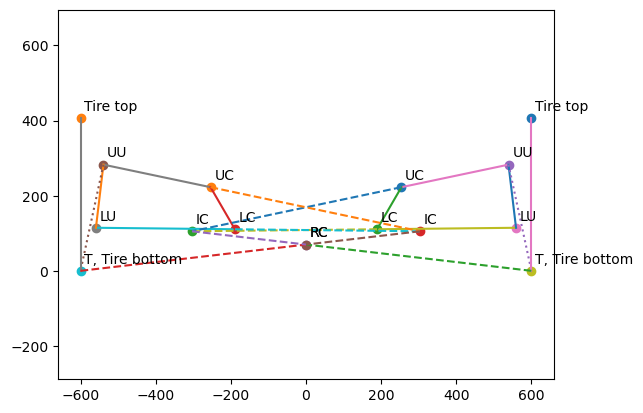

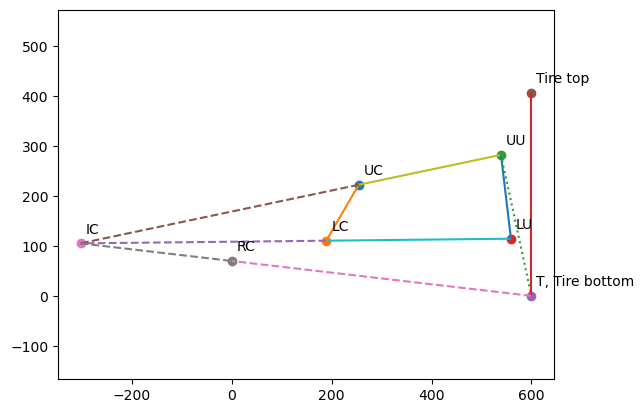

[0.0, 69.93057899202333]
done heave
done roll
C 110.46379497373789 L 370.22830793984406 U 311.1370276903731 Upr 169.18628786045284
RUC 151.31237765617107 RCL -603.9452157924569 RC [0.0, 68.91896457867965]
110.46379497373789 311.1370276903731 370.22830793984406 169.18628786045284 283.5227680451784
2.0122671952654203 15.376251248826192 Upr o -83.21102542556122 63.087003022256326 -80.45794348717148 90.00000000000001 2.753081938389748
0.0
To 2.753081938389748


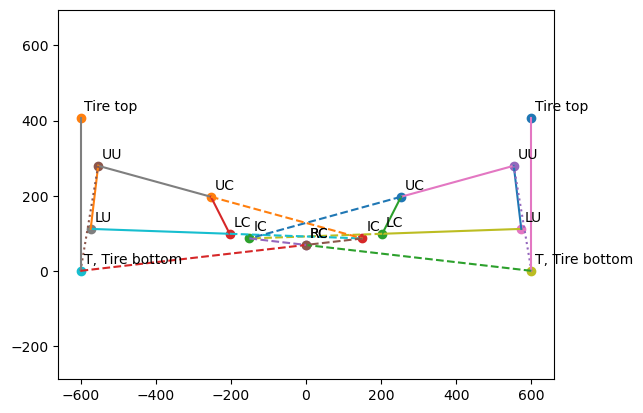

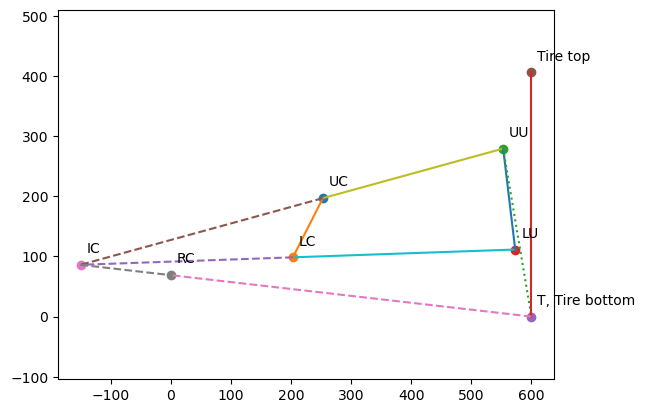

[0.0, 68.91896457867965]
done heave
done roll


In [98]:
# === IMPORTS AND SETUP ===
#%matplotlib qt
#%matplotlib qt
import numpy as np
from scipy.optimize import fsolve
from numpy import sin, cos, pi, arctan
import matplotlib.pyplot as plt
from matplotlib import animation

# === VEHICLE CONFIGURATION ===
# Coordinate system: X+ front, Y+ driver side, Z+ up (roof)
# Chassis and upright hardpoints in mm (Y/Z plane), measured at mid-travel

# Mode definitions:
# mode 0 = fixed track width
# mode 1 = roll center fixed during roll
# mode 2 = roll center free to move
mode = 1
#front= True
#front= False
# === SAMPLING FOR MOTION ANALYSIS ===
steps = 61                  # Number of evaluation points
plotrange = 60              # Range of vertical motion (mm)
stepsize = plotrange / (steps - 1)  # mm per step
angle = 3 / 180 * pi     # Total roll angle in radians
stepang = angle / (steps - 1)  # radians per step
gamma=[]
RCy= []
camber= [-1 * np.pi/180, -1* np.pi/180]

for front in range(2):
    #calculator works by using these hardpoints in calculations, only change these to change the suspension then click run all
    #calculator works by using these hardpoints in calculations, only change these to change the suspension then click run all
    if front ==0:
        # === HARDPOINTS (Y,Z coordinates) ===
        UCy = 280 -19-7
        UCz = 245 -14 -17.4 +8+1
        UC = [UCy, UCz]  # Upper chassis points
        
        LCy = 250-52-5-4
        LCz = (127+135)/2-8 +4-17.4+1
        LC = [LCy, LCz]  # Lower chassis points
        
        UUy = 539
        UUz = 300 -17.4
        UU = [UUy, UUz]  # Upper upright points
        
        LUy = 559
        LUz = 132 -17.4
        LU = [LUy, LUz]  # Lower upright points
    else:
        UCy = 240 +13
        UCz = (197 + 230) / 2 -17.4 +1
        UC = [UCy, UCz]  # Upper chassis points
        
        LCy = 220 -17
        LCz = 120 -6 +1-17.4 +1
        LC = [LCy, LCz]  # Lower chassis points
        
        UUy = 553
        UUz = 295 +2 -17.4
        UU = [UUy, UUz]  # Upper upright points
        
        LUy = 573
        LUz = 130 -1 -17.4
        LU = [LUy, LUz]  # Lower upright points
    
    # === CONTROL ARM LENGTHS ===
    C = ((UCy - LCy)**2 + (UCz - LCz)**2)**0.5  # Chassis vertical span
    L = ((LUy - LCy)**2 + (LUz - LCz)**2)**0.5  # Lower control arm
    U = ((UUy - UCy)**2 + (UUz - UCz)**2)**0.5  # Upper control arm
    Upr = ((UUy - LUy)**2 + (UUz - LUz)**2)**0.5  # Upright
    Ctop = 2 * UCy  # Reference for roll simulation
    Cbot = 2 * LCy
    
    print("C", C, "L", L, "U", U, "Upr", Upr)
    
    # === TIRE AND TRACK MEASUREMENTS ===
    TD = 406.4         # Tire diameter in mm (16 inches)
    TR = TD / 2        # Tire radius
    Track = 600        # Half track width (1 side of the car)
    TCz = 220.6 - 17.4  # Tire center Z coordinate
    Tz = TCz - TR      # Tire bottom contact patch Z coordinate
    TUU = ((Track - UUy)**2 + (Tz - UUz)**2)**0.5  # Length from upper upright to tire patch
    TUC = ((Track - UCy)**2 + (Tz - UCz)**2)**0.5  # Length from upper chassis to tire patch
    T = [Track, Tz]    # Tire contact patch location
    
    # === ANGLE DEFINITIONS ===
    LLCo = arctan((LUz - LCz) / (LUy - LCy))        # Lower control arm
    UUCo = arctan((UUz - UCz) / (UUy - UCy))        # Upper control arm
    UprUUo = arctan((LUz - UUz) / (LUy - UUy))      # Upright
    CLCo = arctan((UCz - LCz) / (UCy - LCy))        # Chassis reference
    TUUo = arctan((Tz - UUz) / (Track - UUy))       # Tire to upper upright
    TUCo = arctan((Tz - UCz) / (Track - UCy))       # Tire to upper chassis
    
    To = TUUo - UprUUo         # Relative upright-to-tire angle
    T90 = pi/2 - TUUo          # Perpendicular direction to tire contact
    TDo = TUUo + T90           # Tire top offset direction
    TDD = [T[0] + TD * cos(TDo), T[1] + TD * sin(TDo)]  # Tire top coordinates
    
    # === INSTANT CENTER ANALYSIS ===
    def ICloop(guess):
        ICL, ICU = guess
        loop = np.zeros(2)
        loop[0] = LC[0] - ICL * cos(LLCo) + ICU * cos(UUCo) - UC[0]
        loop[1] = LC[1] - ICL * sin(LLCo) + ICU * sin(UUCo) - UC[1]
        return loop
    
    guess = [0, 0]
    (ICL, ICU) = fsolve(ICloop, guess)  # Solve for IC link distances
    IC = [LC[0] - ICL * cos(LLCo), LC[1] - ICL * sin(LLCo)]  # IC coordinates
    
    # === ROLL CENTER CALCULATION ===
    TRo = arctan((Tz - IC[1]) / (Track - IC[0]))  # Angle from IC to tire patch
    
    def RCloop(guess):
        RCL, RCU, XXX = guess
        loop = np.zeros(3)
        loop[0] = T[0] + RCL * cos(TRo) - RCU * cos(TRo) - IC[0]
        loop[1] = T[1] + RCL * sin(TRo) - RCU * sin(TRo) - IC[1]
        loop[2] = T[0] + RCL * cos(TRo)  # Symmetry constraint (forces geometry to resolve in one plane)
        return loop
    
    guess = [0, 0, 0]
    (RCL, RCU, XXX) = fsolve(RCloop, guess)
    RC = [T[0] + RCL * cos(TRo), T[1] + RCL * sin(TRo)]  # Roll center coordinates
    
    print("RUC", RCU, "RCL", RCL, "RC", RC)
    
    # === SUMMARY OF GEOMETRY ===
    print(C, U, L, Upr, TUU)
    print(
        LLCo * 360 / (2 * pi), UUCo * 360 / (2 * pi),
        "Upr o", UprUUo * 360 / (2 * pi),
        CLCo * 360 / (2 * pi), TUUo * 360 / (2 * pi),
        TDo * 360 / (2 * pi), To * 360 / (2 * pi)
    )
    print(Tz)  # Z-height of tire bottom (should be ~0)
    print("To", To*180/pi)
    # === VISUALIZATION: SYMMETRIC VIEW ===
    fig, ax = plt.subplots()
    for name, point in zip(['UC','LC','UU','LU','T, Tire bottom', 'Tire top',"IC","RC"], [UC, LC, UU, LU, T, TDD, IC, RC]):
        ax.text(point[0]+10, point[1]+20, name)
        ax.plot(point[0], point[1], "o")
        ax.text(-point[0]+10, point[1]+20, name)   # Mirror image (left side)
        ax.plot(-point[0], point[1], "o")
    
    # Draw lines for all components
    for start, R, O, style in zip(
        [UC, LC, UU, LC, UU, T, LC, UC, T, IC],   # Starting points
        [U, L, Upr, C, TUU, TD, ICL, ICU, RCL, RCU],  # Lengths
        [UUCo, LLCo, UprUUo, CLCo, TUUo, TDo, LLCo + pi, UUCo + pi, TRo, TRo],  # Angles
        ('-', '-', '-', '-', ':', '-', '--', '--', '--', '--')  # Line styles
    ):
        ax.plot([start[0], start[0] + R * cos(O)], [start[1], start[1] + R * sin(O)], style)
        ax.plot([-start[0], -start[0] - R * cos(O)], [start[1], start[1] + R * sin(O)], style)  # Symmetric side
    
    plt.axis('equal')
    plt.show()
    
    # === VISUALIZATION: DRIVER-SIDE ONLY ===
    fig, ax = plt.subplots()
    for name, point in zip(['UC','LC','UU','LU','T, Tire bottom', 'Tire top',"IC","RC"], [UC, LC, UU, LU, T, TDD, IC, RC]):
        ax.text(point[0]+10, point[1]+20, name)
        ax.plot(point[0], point[1], "o")
    
    for start, R, O, style in zip(
        [UC, LC, UU, LC, UU, T, LC, UC, T, IC],
        [U, L, Upr, C, TUU, TD, ICL, ICU, RCL, RCU],
        [UUCo, LLCo, UprUUo, CLCo, TUUo, TDo, LLCo + pi, UUCo + pi, TRo, TRo],
        ('-', '-', '-', '-', ':', '-', '--', '--', '--', '--')
    ):
        ax.plot([start[0], start[0] + R * cos(O)], [start[1], start[1] + R * sin(O)], style)
    
    plt.axis('equal')
    plt.show()

    print(RC)
    
    RCy.append(RC[1])
    
    
    
    
    
    
    
    # Import necessary libraries
    import numpy as np
    from scipy.optimize import fsolve
    from numpy import sin, cos, pi, arctan
    import matplotlib.pyplot as plt
    from matplotlib import animation
    from scipy.optimize import least_squares
    
    # Known suspension geometry parameters 
    knowns = (U, L, C, Upr, T, CLCo, To, TUU, TUC, TUCo)
    
    # Initialize heave motion arrays
    MM = np.zeros((steps))      # Vertical motion (mm input) per step
    LLCO = np.zeros((steps))    # Lower control arm angle
    UUCO = np.zeros((steps))    # Upper control arm angle
    UprUUO = np.zeros((steps))  # Upper upright angle
    ICL = np.zeros((steps))     # Instant center length from lower arm
    ICU = np.zeros((steps))     # Instant center length from upper arm
    IC = np.zeros((steps,2))    # Instant center coordinates
    # Roll center maps for right/left arms (over all motion range)
    RRCL, RRCU, LRCL, LRCU = np.zeros((steps,steps)), np.zeros((steps,steps)), np.zeros((steps,steps)), np.zeros((steps,steps))
    RC = np.zeros((steps,steps,2))  # Roll center location map (Y,Z)
    
    # Initial guess for angle solving (fsolve)
    guessinput = (LLCo, UUCo, UprUUo)
    
    # Solve instant center from vector loop closure
    def ICloop(guess1):
        ICL, ICU = guess1
        loop = np.zeros(2)
        loop[0] = LC[0] - ICL * cos(LLCO[i]) + ICU * cos(UUCO[i]) - UC[0]
        loop[1] = LC[1] - ICL * sin(LLCO[i]) + ICU * sin(UUCO[i]) - UC[1]
        return loop
    
    # Solve 3-vector loop: LC + L + U + Upr + TUC = known chassis coordinates
    def positionloop(guessinput, MM_i, knowns):
        (LLCo, UUCo, UprUUo) = guessinput
        (U, L, C, Upr, T, CLCo, To, TUU, TUC, TUCo) = knowns
        
        try:
            loop = np.zeros(3)
            loop[0] = C*cos(CLCo) + U*cos(UUCo) + Upr*cos(UprUUo) - L*cos(LLCo)
            loop[1] = C*sin(CLCo) + U*sin(UUCo) + Upr*sin(UprUUo) - L*sin(LLCo)
            loop[2] = U*sin(UUCo) + TUU*sin(UprUUo + To) - MM_i - TUC*sin(TUCo)
        except Exception as e:
            print("Math error in positionloop:", e)
            loop = [np.nan, np.nan, np.nan]
        return loop
    
    # Solve geometry at each vertical motion (heave) position
    Guess = np.array([LLCo, UUCo, UprUUo])
    guess1 = [0, 0]
    
    for i in range(steps):
        MM[i] = i * stepsize - 20  # Vertical input sweep, centered at -20 mm
        
        # Solve upper/lower/upright angles that satisfy geometry
        (LLCO[i], UUCO[i], UprUUO[i]) = fsolve(positionloop, Guess, args=(MM[i], knowns))
        Guess = (LLCO[i], UUCO[i], UprUUO[i])
        
        # Solve instant center lengths for given configuration
        (ICL[i], ICU[i]) = fsolve(ICloop, guess1)
        guess1 = [ICL[i], ICU[i]]
        
        # Compute IC coordinates
        IC[i] = LC[0] - ICL[i] * cos(LLCO[i]), LC[1] - ICL[i] * sin(LLCO[i])
    
    # Compute roll centers across all combinations of left/right travel
    T = np.zeros((steps, 2))     # Tire contact point
    TRo = np.zeros((steps))      # Tire to IC angle (right)
    CTRo = np.zeros((steps))     # cos(TRo)
    STRo = np.zeros((steps))     # sin(TRo)
    
    for i in range(steps):
        T[i] = [UC[0] + U*cos(UUCO[i]) + TUU*cos(UprUUO[i] + To),
                UC[1] + U*sin(UUCO[i]) + TUU*sin(UprUUO[i] + To)]
        
        TRo[i] = arctan((T[i][1] - IC[i][1]) / (T[i][0] - IC[i][0]))
        CTRo[i] = cos(TRo[i])
        STRo[i] = sin(TRo[i])
    
    # Closure equation for roll center geometry solving
    def RCloop(guess2):
        rRCL, rRCU, lRCL, lRCU, xxx, yyy = guess2
        loop = np.zeros(6)
        loop[0] = T[r][0] + rRCL*CTRo[r] - rRCU*CTRo[r] - IC[r][0]
        loop[1] = T[r][1] + rRCL*STRo[r] - rRCU*STRo[r] - IC[r][1]
        loop[2] = -T[l][0] + lRCL*CTRo[l] - lRCU*CTRo[l] + IC[l][0]
        loop[3] = T[l][1] + lRCL*(-STRo[l]) - lRCU*(-STRo[l]) - IC[l][1]
        loop[4] = T[r][0] + rRCL*CTRo[r] - lRCU*CTRo[l] + IC[l][0]
        loop[5] = T[r][1] + rRCL*STRo[r] - lRCU*(-STRo[l]) - IC[l][1]
        return loop
    
    # Loop over all heave pairings and solve roll center location
    for l in range(steps):
        for r in range(steps):
            if r >= l:
                guess2 = [0, 0, 0, 0, 0, 0]
                xxx = yyy = 0
                (RRCL[r][l], RRCU[r][l], LRCL[r][l], LRCU[r][l], xxx, yyy) = fsolve(RCloop, guess2)
                RC[r][l][0] = T[r][0] + RRCL[r][l] * cos(TRo[r])
                RC[r][l][1] = T[r][1] + RRCL[r][l] * sin(TRo[r])
            else:
                RC[r][l][0] = -RC[l][r][0]  # symmetry exploitation
                RC[r][l][1] = RC[l][r][1]
                RRCL[r][l], RRCU[r][l], LRCL[r][l], LRCU[r][l] = RRCL[l][r], RRCU[l][r], LRCL[l][r], LRCU[l][r]
    
    print("done heave")
    
    # Initialize roll variables
    A = np.zeros((steps))        # Roll angle input (in radians)
    LLCOA = np.zeros((steps))    # LCA angle - left
    LLCOB = np.zeros((steps))    # LCA angle - right
    UUCOA = np.zeros((steps))    # UCA angle - left
    UUCOB = np.zeros((steps))    # UCA angle - right
    UprUUOA = np.zeros((steps))  # Upright angle - left
    UprUUOB = np.zeros((steps))  # Upright angle - right
    
    # Instant center lengths
    ICLA = np.zeros((steps))
    ICUA = np.zeros((steps))
    ICLB = np.zeros((steps))
    ICUB = np.zeros((steps))
    
    # Roll center arm vectors
    RCLA = np.zeros((steps))
    RCUA = np.zeros((steps))
    RCLB = np.zeros((steps))
    RCUB = np.zeros((steps))
    Track = np.zeros((steps))   # Track width during roll
    
    # Coordinates of suspension points
    UCA = np.zeros((steps,2))
    UCB = np.zeros((steps,2))
    LCA = np.zeros((steps,2))
    LCB = np.zeros((steps,2))
    ICA = np.zeros((steps,2))
    ICB = np.zeros((steps,2))
    
    # Tire-to-IC angles
    TROA = np.zeros((steps))
    TROB = np.zeros((steps))
    
    # Final roll center coordinates across all roll states
    RCroll = np.zeros((steps,2))
    
    # Assign all knowns for fsolve loop
    knowns = (U, L, C, Ctop, Cbot, Upr, CLCo, To, TUU, TUC, TUCo)
    
    # Closure equation for roll configuration solving
    def Rollloop(guessinput, a, knowns):
        # Unpack current guess and known values
        (LLCoa, LLCob, UUCoa, UUCob, UprUUoa, UprUUob, track, xxx, xxx1, xxx2, xxx3) = guessinput
        (U, L, C, Ctop, Cbot, Upr, CLCo, To, TUU, TUC, TUCo) = knowns
    
        # Lock track width if mode==0
        if mode == 0:
            track = 1200
    
        # Construct all control arm and upright vectors based on geometry
        UCa = [track/2 - (-TUU*cos(pi - UprUUoa - To) - U*cos(pi - UUCoa)),
               -TUU*sin(pi - UprUUoa - To) - U*sin(pi - UUCoa)]
        
        UCb = [track/2 + (-U*cos(UUCob) - TUU*cos(UprUUob + To)),
               -U*sin(UUCob) - TUU*sin(UprUUob + To)]
    
        LCa = [track/2 - (-TUU*cos(pi - UprUUoa - To) + Upr*cos(pi - UprUUoa) - L*cos(pi - LLCoa)),
               -TUU*sin(pi - UprUUoa - To) + Upr*sin(pi - UprUUoa) - L*sin(pi - LLCoa)]
    
        LCb = [track/2 + (-L*cos(LLCob) + Upr*cos(UprUUob) - TUU*cos(UprUUob + To)),
               -L*sin(LLCob) + Upr*sin(UprUUob) - TUU*sin(UprUUob + To)]
    
        # Vector loop constraints (position closure equations)
        loop = np.zeros(11)
        loop[0] = UCa[1] + Ctop*sin(a) - UCb[1]
        loop[1] = -UCa[0] + Ctop*cos(a) - UCb[0]
        loop[2] = LCa[1] + Cbot*sin(a) - LCb[1]
        loop[3] = -LCa[0] + Cbot*cos(a) - LCb[0]
        loop[4] = LCa[0] + C*cos(CLCo - a) - UCa[0]
        loop[5] = LCa[1] + C*sin(CLCo - a) - UCa[1]
        loop[6] = LCb[0] + C*cos(CLCo + a) - UCb[0]
        loop[7] = LCb[1] + C*sin(CLCo + a) - UCb[1]
        loop[8] = C*sin(CLCo + a) + Ctop*sin(a) - Cbot*sin(a) - C*sin(pi - CLCo + a)
        loop[9] = C*cos(CLCo + a) + Ctop*cos(a) - Cbot*cos(a) - C*cos(pi - CLCo + a)
    
        # Instant center solving via direct matrix solve
        ICar = [[-cos(LLCoa), cos(UUCoa), 0, 0],
                [-sin(LLCoa), sin(UUCoa), 0, 0],
                [0, 0, -cos(LLCob), cos(UUCob)],
                [0, 0, -sin(LLCob), sin(UUCob)]]
    
        ICve = [[UCa[0] - LCa[0]],
                [UCa[1] - LCa[1]],
                [UCb[0] - LCb[0]],
                [UCb[1] - LCb[1]]]
    
        # Solve for arm lengths from joint to IC
        [ICLA[i], ICUA[i], ICLB[i], ICUB[i]] = np.linalg.solve(ICar, np.squeeze(ICve))
    
        # Use arm angles and lengths to get IC coordinates
        ICa = [LCa[0] - ICLA[i]*cos(LLCoa), LCa[1] - ICLA[i]*sin(LLCoa)]
        ICb = [LCb[0] - ICLB[i]*cos(LLCob), LCb[1] - ICLB[i]*sin(LLCob)]
    
        # Compute tire-to-IC angles (roll axis projection)
        TRoa = arctan((-ICa[1]) / (track/2 - ICa[0]))
        TRob = arctan((-ICb[1]) / (track/2 - ICb[0]))
    
        # Set up matrix for solving roll center locations
        RCar = [[cos(TRoa), -cos(TRoa), 0, 0],
                [sin(TRoa), -sin(TRoa), 0, 0],
                [0, 0, cos(TRob), -cos(TRob)],
                [0, 0, sin(TRob), -sin(TRob)],
                [0, -cos(pi - TRoa), cos(TRob), 0],
                [0, -sin(pi - TRoa), sin(TRob), 0]]
    
        RCve = [[ICa[0] - track/2],
                [ICa[1]],
                [ICb[0] - track/2],
                [ICb[1]],
                [-ICa[0] - track/2],
                [ICa[1]]]
    
        # Solve least squares for roll center arm lengths
        [RCLA[i], RCUA[i], RCLB[i], RCUB[i]] = np.linalg.lstsq(RCar, np.squeeze(RCve), rcond=None)[0]
    
        # Compute roll center global coordinate
        RCroll[i] = [track/2 + RCLB[i]*cos(TRob), RCLB[i]*sin(TRob)]
    
        # Final constraint used to pin roll center movement during mode-based sweep
        switch = [track - 1200, RCroll[i][1] - RC[int((steps-1)/3)][int((steps-1)/3)][1], 0]
        loop[10] = switch[mode]
    
        return loop
    
    # Initial guess for roll sweep
    guess3 = [LLCo, LLCo, UUCo, UUCo, UprUUo, UprUUo, 1200, 0, 0, 0, 0]
    
    # Roll sweep loop — iterate over roll angles to find geometry that satisfies all loops
    for i in range(steps):
        A[i] = i * stepang  # Angle of body roll
    
        # Solve full position + IC + roll center equations
        sol, info, ier, msg = fsolve(Rollloop, guess3, args=(A[i], knowns), full_output=True)
    
        # Store result and feed forward to next guess
        (LLCOA[i], LLCOB[i], UUCOA[i], UUCOB[i], UprUUOA[i], UprUUOB[i], Track[i], xxx, xxx1, xxx2, xxx3) = sol
        guess3 = [LLCOA[i], LLCOB[i], UUCOA[i], UUCOB[i], UprUUOA[i], UprUUOB[i], Track[i], 0, 0, 0, 0]
    
        # Lock track if needed
        if mode == 0:
            Track[i] = 1200
    
        # Recompute physical coordinates of arms and ICs
        UCA[i] = [Track[i]/2 - (-TUU * cos(pi - UprUUOA[i] - To) - U * cos(pi - UUCOA[i])),
                  -TUU * sin(pi - UprUUOA[i] - To) - U * sin(pi - UUCOA[i])]
    
        UCB[i] = [Track[i]/2 + (-U * cos(UUCOB[i]) - TUU * cos(UprUUOB[i] + To)),
                  -U * sin(UUCOB[i]) - TUU * sin(UprUUOB[i] + To)]
    
        LCA[i] = [Track[i]/2 - (-TUU * cos(pi - UprUUOA[i] - To) + Upr * cos(pi - UprUUOA[i]) - L * cos(pi - LLCOA[i])),
                  -TUU * sin(pi - UprUUOA[i] - To) + Upr * sin(pi - UprUUOA[i]) - L * sin(pi - LLCOA[i])]
    
        LCB[i] = [Track[i]/2 + (-L * cos(LLCOB[i]) + Upr * cos(UprUUOB[i]) - TUU * cos(UprUUOB[i] + To)),
                  -L * sin(LLCOB[i]) + Upr * sin(UprUUOB[i]) - TUU * sin(UprUUOB[i] + To)]
    
        # Instant center coordinates
        ICA[i] = [LCA[i, 0] - ICLA[i] * cos(LLCOA[i]), LCA[i, 1] - ICLA[i] * sin(LLCOA[i])]
        ICB[i] = [LCB[i, 0] - ICLB[i] * cos(LLCOB[i]), LCB[i, 1] - ICLB[i] * sin(LLCOB[i])]
    
        # Tire-to-IC angles
        TROA[i] = arctan((-ICA[i, 1]) / (Track[i]/2 - ICA[i, 0]))
        TROB[i] = arctan((-ICB[i, 1]) / (Track[i]/2 - ICB[i, 0]))
    
    print("done roll")
    gamma1, gamma2= [],[]
    for i in range(steps):
        gamma1.append(-((UprUUOA[i]+To+T90)-pi/2)+camber[front])
        gamma2.append(+((UprUUOB[i]+To+T90)-pi/2)-camber[front])
    gamma.append(gamma1)
    gamma.append(gamma2)















In [99]:
#print(RCy)
#print(gamma)

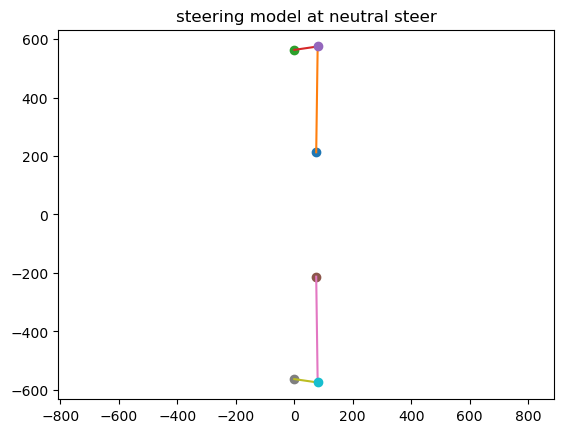

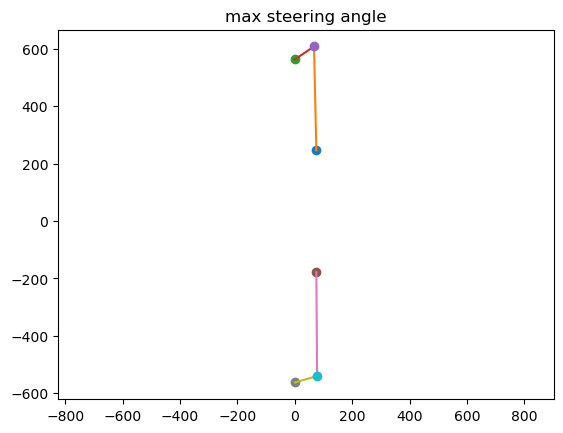

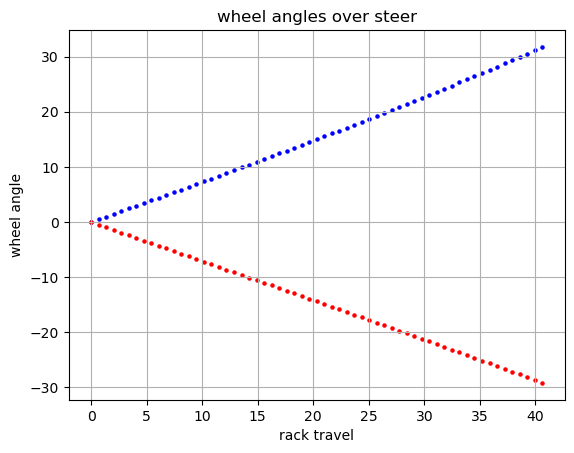

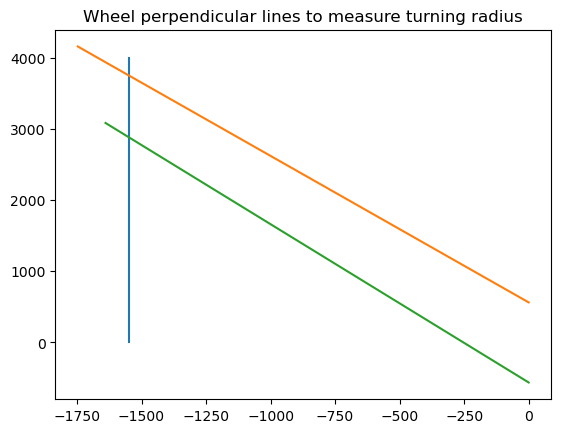

ackerman angle: 8.25
front wheels intersection radius top calculated in x,y [-6789.172328889167, 14546.45586446159]
front wheels intersection radius bottom calculated in x,y [-6789.172328889167, 14546.45586446159]


In [100]:
#steering---------------

#variable inputs
ep= 1e-6

rackx = 75 #rack position
racky = 425.4
racky2= racky/2

pivoty = (553+573)/2 #pivot of the upright
pivotx = 0

ackx= 80 #tie rod connector point
ackang = 33/4 *np.pi/180 #33 is what ive found 100% ackerman
acky= ackx * np.tan(ackang)

#print(pivoty +acky)
tie= ((-rackx+ackx)**2 + (-racky2 +acky +pivoty)**2)**(1/2)

dist= 82.55/2 #travel of rack

tieang = np.arctan2(-(-racky2 +acky),(-rackx+ackx))
ack= ((pivotx-ackx)**2 + (acky)**2)**(1/2)

wheelbase= 1550
track = 1200
CGx= .55 #percent away from front
stepPer=.3


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

#plot 1 is nuetral steer, 
#plot 2 is full steer to the left, 
#plot 3 is the wheel angles, 
#plot 4 isfinding where the tires will intersect

#print(tie, ack)
#print(tieang*180/np.pi,ackang*180/np.pi) 
plt.plot(rackx, racky2, "o")
plt.plot([rackx,pivotx+ackx], [racky2,pivoty +acky], "-")
plt.plot(pivotx, pivoty, "o")
plt.plot([pivotx,pivotx+ackx], [pivoty,pivoty +acky], "-")
plt.plot(pivotx+ackx, pivoty +acky, "o")

plt.plot(rackx, -racky2, "o")
plt.plot([rackx,pivotx+ackx], [-racky2,-pivoty -acky], "-")
plt.plot(pivotx, -pivoty, "o")
plt.plot([pivotx,pivotx+ackx], [-pivoty,-pivoty -acky], "-")
plt.plot(pivotx+ackx, -pivoty -acky, "o")
plt.axis('equal')

plt.title("steering model at neutral steer")
plt.show()

#print(ackang/np.pi*180)
steps=steps
MM = np.empty([2,steps])
Tieang= np.empty([2,steps])
ang = np.empty([2,steps])

for n in range(2):
    
    guess= [tieang, 0]
    def ackerman(guess,mm):
        (TieAng, Ang) = guess
        loop = np.empty(2)
        loop[0]= mm +racky2 + np.sin(TieAng)*tie - np.sin(Ang+ackang)*ack -pivoty
        loop[1]= rackx + np.cos(TieAng)*tie - np.cos(Ang+ackang)*ack -pivotx
        return loop

    for i in range(steps):
        MM[n,i]= (-1)**n * i *dist/steps
        #print(MM[n,i])
        (Tieang[n,i], ang[n,i]) = fsolve(ackerman, guess, args=(MM[n,i]))
        guess = (Tieang[n,i], ang[n,i])
        #print(Tieang[n,i]/np.pi*180,ang[n,i]/np.pi*180)
    #print("\n")
    
for n in range(2):
    i=50
    plt.plot(rackx, (-1)**n *(racky2 +MM[n,i]), "o")
    plt.plot([rackx,pivotx+ack*np.cos(ang[n,i]+ackang)], [(-1)**n *(racky2 +MM[n,i]),(-1)**n *(pivoty +ack*np.sin(ang[n,i]+ackang))], "-")
    plt.plot(pivotx, (-1)**n *pivoty, "o")
    plt.plot([pivotx,pivotx+ack*np.cos(ang[n,i]+ackang)], [(-1)**n *(pivoty),(-1)**n *(pivoty +ack*np.sin(ang[n,i]+ackang))], "-")
    plt.plot(pivotx+ack*np.cos(ang[n,i]+ackang), (-1)**n *(pivoty +ack*np.sin(ang[n,i]+ackang)), "o")
plt.axis('equal')

plt.title("max steering angle")
plt.show()

fig, ax = plt.subplots()
for n in range(2):
    col= ["blue","red"]
    for i in range(steps):
        ax.scatter(MM[0,i],ang[n,i]/np.pi*180, s=5, color=col[n])
plt.xlabel("rack travel")
plt.ylabel("wheel angle")
ax.set_title("wheel angles over steer")
plt.grid(True)
plt.show()

i=50
x=4000
#print(ang[0,i])
plt.plot([-1*wheelbase,-1*wheelbase],[0,x],"-")
plt.plot([pivotx,pivotx+x*np.cos(ang[0,i]+np.pi/2)],[pivoty,pivoty+x*np.sin(ang[0,i]+np.pi/2)],"-")
plt.plot([pivotx,pivotx-x*np.cos(ang[1,i]+np.pi/2)],[-pivoty,-pivoty+x*np.sin(ang[1,i]+np.pi/2)],"-")
#plt.axis('equal')

plt.title("Wheel perpendicular lines to measure turning radius")
plt.show()

A= [[np.cos(ang[0,i]+np.pi/2),np.cos(-ang[1,i]+np.pi/2)],
    [np.sin(ang[0,i]+np.pi/2),np.sin(ang[1,i]+np.pi/2)]]
a=[0, -pivoty*2]
#print(A)
b=np.linalg.solve(A,a)
print("ackerman angle:",ackang*180/np.pi)
print("front wheels intersection radius top calculated in x,y",[b[0]*np.cos(ang[0,i]+np.pi/2),b[0]*np.sin(ang[0,i]+np.pi/2)+pivoty])
print("front wheels intersection radius bottom calculated in x,y",[-b[1]*np.cos(-ang[1,i]+np.pi/2),-b[1]*np.sin(ang[1,i]+np.pi/2)-pivoty])

0
rear [37.06836199 37.14211151 37.28935113 37.43589281 37.58167228 37.72662306
 37.87067631 38.01376077 38.15580264 38.2967255  38.43645021 38.57489479
 38.71197432 38.84760084 38.98168322 39.11412707 39.24483458 39.37370443
 39.50063164 39.62550746 39.74821921 39.86865016 39.98667937 40.10218156
 40.21502693 40.32508103 40.43220461 40.5362534  40.63707799 40.73452365
 40.82843012 40.91863147 41.00495587 41.08722544 41.16525601 41.23885697
 41.30783101 41.37197396 41.43107456 41.48491422 41.53326685 41.57589861
 41.6125677  41.6430241  41.66700942 41.68425658 41.69448967 41.69742367
 41.69276424 41.68020752 41.6594399  41.63013781 41.59196753 41.54458498
 41.48763557 41.42075398 41.34356409 41.25567878 41.15669979 41.04621771
 40.98807179]
0
K(z) = -0.002033*z² + -0.116458*z + 39.882586
1
front [25.95786586 25.99637962 26.07368481 26.15146676 26.22968132 26.30828309
 26.38722533 26.46645985 26.54593684 26.62560483 26.70541046 26.78529845
 26.86521135 26.9450895  27.02487082 27.1044906

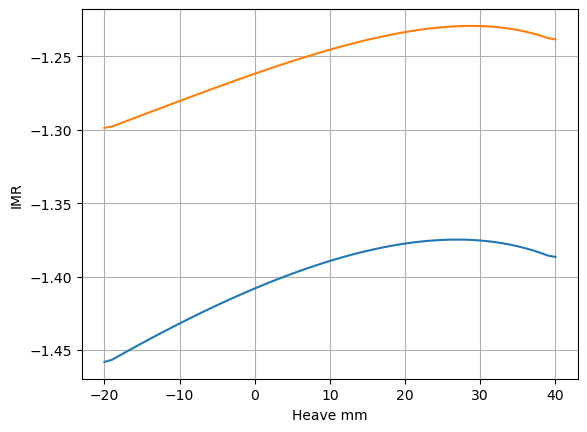

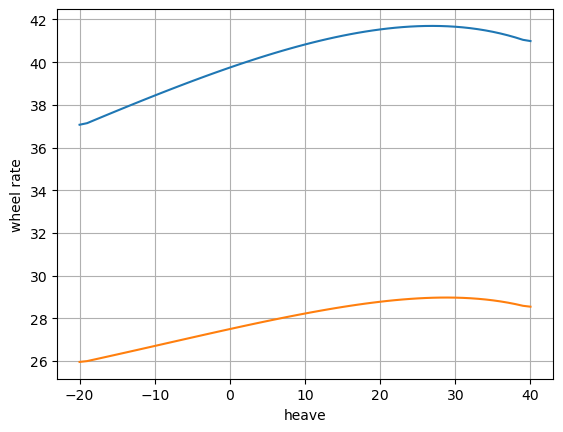

[25.701832218579558, 26.153897956809853, 26.571265044321553, 26.95393348111466, 27.30190326718917, 27.61517440254509, 27.893746887182413, 28.137620721101143, 28.34679590430128, 28.521272436782823, 28.661050318545772, 28.766129549590126, 28.836510129915887, 28.87219205952305, 28.873175338411624, 28.8394599665816, 28.771045944032984, 28.667933270765772, 28.530121946779968, 28.35761197207557, 28.150403346652578]
[36.740098273794246, 37.49872933308955, 38.19229359258699, 38.820791052286566, 39.38422171218828, 39.88258557229212, 40.315882632598104, 40.68411289310621, 40.98727635381646, 41.225373014728845, 41.39840287584336, 41.506365937160005, 41.54926219867879, 41.52709166039971, 41.439854322322766, 41.28755018444795, 41.070179246775275, 40.78774150930473, 40.44023697203632, 40.02766563497004, 39.550027498105905]


In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
#x is front back of car
#y is left right
#z is vertical
front=0
steps= 61


Kfront=[]
Krear=[]
for abc in range(2):
    print(abc)
    front= abc
    
    if front==0:
       DampYZ= [
           [0.18205716816191853, -14.967091124481797], [0.19138278558210686, -14.21622800232143],\
             [0.19875641631631424, -13.46562106904895], [0.20418019692436928, -12.715271589253007],         [0.20765623674020617, -11.965180838766045], [0.20918661815119322, -11.215350104300683],\
             [0.20877339686961705, -10.465780683511568], [0.2064186022022909, -9.716473885057226],         [0.20212423731737772, -8.967431028664052], [0.19589227951018984, -8.218653445188977],\
             [0.18772468046614676, -7.47014247668281], [0.1776233665227096, -6.721899476455903],         [0.16559023892864388, -5.97392580914088], [0.15162717410203186, -5.226222850759797],\
             [0.1357360238863521, -4.478791988787194], [0.1179186158047969, -3.731634622222316],         [0.0981767533129414, -2.984752161647691], [0.0765122160501619, -2.2381460293046302],\
             [0.05292676008826902, -1.4918176591386185], [0.02742211818110718, -0.7457684969206468],         [9.549694368615746e-12, -2.5001156700454885e-10], [-0.029337907572937638, 0.7454863613364324],\
             [-0.060589940296324585, 1.4906891063063767], [-0.09375445623186351, 2.2356067410584473],         [-0.12882983555130068, 2.9802377598560668], [-0.16581448028688328, 3.724580644756884],\
             [-0.2047068140929582, 4.468633865535381], [-0.24550528200865074, 5.212395879619777],         [-0.2882083502217938, 5.9558651320143525], [-0.3328145058337668, 6.699040055229858],\
             [-0.37932225662575547, 7.441919069210741], [-0.42773013082552325, 8.184500581258732],         [-0.47803667687566076, 8.926782985964195], [-0.5302404632030289, 9.668764665130567],\
             [-0.5843400779880312, 10.41044398769779], [-0.6403341289358764, 11.151819309669548],         [-0.6982212430484651, 11.892888974040744], [-0.7580000663966757, 12.633651310718307],\
             [-0.8196692638937861, 13.374104636446532], [-0.8832275190697487, 14.114247254733044],         [-0.9486735338456924, 14.854077455770891], [-1.0160060283097891, 15.593593516362063],\
             [-1.0852237404931202, 16.33279369984143], [-1.1563254261466227, 17.071676255998455],         [-1.2293098585184339, 17.810239421001086], [-1.3041758281316902, 18.54848141731557],\
             [-1.3809221425632927, 19.28640045363187], [-1.4595476262223315, 20.02399472478203],         [-1.5400511201301583, 20.76126241166449], [-1.6224314816994934, 21.498201681162385],\
             [-1.7066875845153504, 22.234810686067277], [-1.792818318115053, 22.97108756499773],         [-1.8808225877696714, 23.707030442320956], [-1.9706993142648912, 24.44263742807314],\
             [-2.0624474336827916, 25.177906617878875], [-2.156065897183794, 25.912836092871913],         [-2.2515536707880983, 26.647423919613686], [-2.348909735158827, 27.381668150014917],\
             [-2.4481330853835743, 28.11556682125334], [-2.5492227307573216, 28.84911795569289],         [-2.652177694565353, 29.582319560804166]]   
    
    if front==1:
        DampYZ =[[1.5992368891999718, -15.975501354499244], [1.5389542770377602, -15.172889406924895], [1.4765893030337907, -14.37067460329186], [1.4121439023202242, -13.568858012790628], [1.3456199799392152, -12.76744071705889], [1.2770194111016053, -11.966423810315618], [1.2063440414352726, -11.16580839940437], [1.1335956872338215, -10.365595603851347], [1.058776135697201, -9.565786555871412], [0.9818871451801101, -8.766382400481831], [0.9029304454284102, -7.967384295503251], [0.821907737816332, -7.16879341160157], [0.7388206955862415, -6.370610932377332], [0.6536709640801064, -5.572838054385073], [0.5664601609726674, -4.775475987196614], [0.4771898765011997, -3.9785259534483544], [0.3858616736939666, -3.1819891888960683], [0.2924770885967405, -2.385866942467601], [0.19703763049744794, -1.590160476317351], [0.09954478214871187, -0.7948710658770608], [-1.0629719326971099e-11, 8.432721188000869e-11], [-0.10159528563616504, 0.7944514194070678], [-0.20523967026031187, 1.5884818764847068], [-0.31093177507568726, 2.3820900422052773], [-0.4186702467209784, 3.1752745738950807], [-0.5284537570678367, 3.9680341152611334], [-0.6402810030086812, 4.7603672963282975], [-0.7541507062471737, 5.552272733383205], [-0.8700616130892058, 6.343749028912441], [-0.9880124942358748, 7.13479477154246], [-1.108002144576858, 7.925408535976487], [-1.2300293829865154, 8.715588882933673], [-1.3540930521200494, 9.505334359085623], [-1.4801920182111985, 10.294643496993274], [-1.6083251708717512, 11.083514815042065], [-1.7384914228912294, 11.871946817377847], [-1.8706897100390165, 12.659937993842448], [-2.0049189908659173, 13.447486819905919], [-2.1411782465081615, 14.234591756600963], [-2.2794664804923173, 15.021251250456999], [-2.4197827185400342, 15.807463733429813], [-2.562126008375458, 16.593227622836537], [-2.706495419532132, 17.378541321283677], [-2.852890043161949, 18.163403216600983], [-3.0013089918439277, 18.9478116817686], [-3.1517513993948683, 19.731765074848198], [-3.304216420679893, 20.51526173891196], [-3.458703231424522, 21.298300001969352], [-3.615211028027261, 22.080878176897528], [-3.773739027372585, 22.862994561366662], [-3.934286466645176, 23.644647437767276], [-4.096852603144498, 24.425835073137108], [-4.261436714100171, 25.20655571908611], [-4.428038096487626, 25.986807611721503], [-4.596656066845128, 26.766588971573952], [-4.767289961090398, 27.545898003519824], [-4.939939134338431, 28.324732896706422], [-5.114602960719708, 29.10309182447469], [-5.291280833198755, 29.880972944281865], [-5.469972163393038, 30.65837439762396], [-5.6506763813927705, 31.435294309957442]]
        
    if front==0:    
        UprAtt= [-1541,478,133] #outer pickup point on control rod
        Bell1 = [-1520.6,280.9,336.7] #pushrod
        
        
        BellPiv= [-1493.14,250.95,296.25] #bellcrank pivot
        
        
        Bell2 = [-1470.80,184.08,315.55] #damper 
        ChasAtt = [-1404,167,149] #pickup point on chassis
        
        #alpha=289/411 *.55
    
    if front==1:
        """UprAtt= [-40.6,455.9,250]
        Bell1 = [-27.9,269.9,131.6] #pushrod
        
        BellPiv= [-61.3,224.6,142.2] #bellcrank pivot
        
        
        Bell2 = [-79.8,330,221.5] #damper 
        ChasAtt = [-253.66,256.87,368.22]
    
        #alpha= 202.9/347 *.62"""
        """UprAtt= [-47,490,275]
        Bell1 = [-36.917,273.47,143.99] #pushrod
        
        
        BellPiv= [-72.71,216.76, 147.90] #bellcrank pivot
        BellPiv= [-73.06,219.112,149.79] #bellcrank pivot
        
        
    
        Bell2 = [-75.46,336.18,227.25] #damper 
        ChasAtt = [-206.39, 263.16, 327.42]
        ChasAtt = [-206.47, 273.25, 333.94]"""

        UprAtt= [-33,508, 137.2]
        Bell1 = [-33,283.11,630] #pushrod
        #Bell1 = [-33,285.33,632.2] #pushrodB
        #Bell1 = [-33,285.64,631.1] #pushrodB
        
        
        
        BellPiv= [-33,218.3,590.8] #bellcrank pivot
        
        
    
        Bell2 = [-33,190.1,663.5] #damper 
        ChasAtt = [-33, 23.25,601.2]
    
    
    Bell1ar= np.array(Bell1)-np.array(BellPiv)
    Bell2ar= np.array(Bell2)-np.array(BellPiv)
    B1norm=Bell1ar/np.linalg.norm(Bell1ar)
    B2norm=Bell2ar/np.linalg.norm(Bell2ar)
    #BellAx= np.cross(Bell1ar,Bell2ar)
    BellAx= np.cross(B1norm,B2norm)
    
    #print(BellAx)
    BellAxNorm= BellAx/np.linalg.norm(BellAx)
    
    rod= ((UprAtt[0]-Bell1[0])**2 + (UprAtt[1]-Bell1[1])**2 + (UprAtt[2]-Bell1[2])**2)**(1/2)
    damp= ((ChasAtt[0]-Bell2[0])**2 + (ChasAtt[1]-Bell2[1])**2 + (ChasAtt[2]-Bell2[2])**2)**(1/2)
    bell1= ((BellPiv[0]-Bell1[0])**2 + (BellPiv[1]-Bell1[1])**2 + (BellPiv[2]-Bell1[2])**2)**(1/2)
    bell2= ((BellPiv[0]-Bell2[0])**2 + (BellPiv[1]-Bell2[1])**2 + (BellPiv[2]-Bell2[2])**2)**(1/2)
    bell3= ((Bell1[0]-Bell2[0])**2 + (Bell1[1]-Bell2[1])**2 + (Bell1[2]-Bell2[2])**2)**(1/2)
    bellax= ((BellPiv[0]-BellAx[0])**2 + (BellPiv[1]-BellAx[1])**2 + (BellPiv[2]-BellAx[2])**2)**(1/2)
    
    
    def angles_from_vec(v):
        v = np.asarray(v, float)
        L = np.linalg.norm(v)
        if L == 0: return 0.0, 0.0
        vx, vy, vz = v / L
        theta = np.arcsin(vz)          
        phi   = np.arctan2(vx, vy)    
        return theta, phi
    # Measured directions for a good initial guess
    r_vec  = np.array(Bell1)   - np.array(UprAtt)  
    b3_vec = np.array(Bell2)   - np.array(Bell1)     
    z_vec  = np.array(ChasAtt) - np.array(Bell2)      
    b1_vec = np.array(Bell1)   - np.array(BellPiv)    
    b2_vec = np.array(Bell2)   - np.array(BellPiv)    
    
    X1,X2   = angles_from_vec(r_vec)
    X3,X4   = angles_from_vec(b3_vec)
    X5,X6   = angles_from_vec(z_vec)
    X7,X8   = angles_from_vec(b1_vec)
    X9,X10  = angles_from_vec(b2_vec)
    
    
    def d(theta, phi,x):
        #all angles are from Y+
        #theta %= 2* np.pi
        #phi %= 2* np.pi
        if x==0:
            y=float(np.cos(theta)*np.sin(phi)) #X
        if x==1:
            y=float(np.cos(theta)*np.cos(phi)) #Y
        if x==2:    
            y=float(np.sin(theta)) #Z
        return y
    
    
    def loop(vars,dY,dZ):
        X1,X2,X3,X4,X5,X6,X7,X8,X9, X10,X = vars
        
        loop=np.empty(11)
    
        loop[0]=(UprAtt[0]    + d(X1,X2,0)*rod+  d(X3,X4,0)*bell3+  d(X5,X6,0)*(damp+X)- ChasAtt[0])
        loop[1]=(UprAtt[1]+ dY + d(X1,X2,1)*rod+  d(X3,X4,1)*bell3+  d(X5,X6,1)*(damp+X)- ChasAtt[1])
        loop[2]=(UprAtt[2]+ dZ + d(X1,X2,2)*rod+  d(X3,X4,2)*bell3+  d(X5,X6,2)*(damp+X)- ChasAtt[2])
    
        #loop[3]=(d(X7,X8,0)*bell1+  d(X3,X4,0)*bell3-  d(X9,X10,0)*bell2)
        #loop[4]=(d(X7,X8,1)*bell1+  d(X3,X4,1)*bell3-  d(X9,X10,1)*bell2)
        #loop[5]=(d(X7,X8,2)*bell1+  d(X3,X4,2)*bell3-  d(X9,X10,2)*bell2)           
    
        loop[3]=(UprAtt[0]    + d(X1,X2,0)*rod-  d(X7,X8,0)*bell1  - BellPiv[0])
        loop[4]=(UprAtt[1]+ dY + d(X1,X2,1)*rod-  d(X7,X8,1)*bell1  - BellPiv[1])
        loop[5]=(UprAtt[2]+ dZ + d(X1,X2,2)*rod-  d(X7,X8,2)*bell1  - BellPiv[2])
    
    
        loop[6] =(BellPiv[0] +d(X9,X10,0)*bell2+  d(X5,X6,0)*(damp+X)- ChasAtt[0])
        loop[7]=(BellPiv[1] +d(X9,X10,1)*bell2+  d(X5,X6,1)*(damp+X)- ChasAtt[1])
        loop[8]=(BellPiv[2] +d(X9,X10,2)*bell2+  d(X5,X6,2)*(damp+X)- ChasAtt[2])
    
        bell1ar= np.array([d(X7,X8,0) *bell1,d(X7,X8,1) *bell1,d(X7,X8,2) *bell1])
        bell2ar= np.array([d(X9,X10,0)*bell2,d(X9,X10,1)*bell2,d(X9,X10,2)*bell2])
        b1pos = BellPiv + bell1ar
        b2pos = BellPiv + bell2ar
        b1norm=bell1ar/np.linalg.norm(bell1ar)
        b2norm=bell2ar/np.linalg.norm(bell2ar)
        bellCurr= np.cross(b1norm,b2norm)
        bellCurrNorm=bellCurr/np.linalg.norm(bellCurr)
        #loop[9]= np.dot(bellCurrNorm, BellAxNorm)-1
        #loop[10] = np.dot(b1pos - b2pos, b1pos - b2pos) - bell3**2
        #loop[10]= 1000*(np.dot(b1norm, b2norm)- np.dot(B1norm, B2norm))  $bettre mathematically but not with fsovle
        
        loop[9]= np.dot(bell1ar/ np.linalg.norm(bell1ar), BellAx / np.linalg.norm(BellAx))
        loop[10]= np.dot(bell2ar/ np.linalg.norm(bell2ar), BellAx / np.linalg.norm(BellAx))  #(Does not wiggle when i used these), les rigid
        #print(Z)
        return loop
    X=5
    n=20
    initial_guess = [X1,X2,X3,X4,X5,X6,X7,X8,X9,X10, 0.0] 
    #print(loop(initial_guess,X))
    solution1 = fsolve(loop, initial_guess, args= (DampYZ[n][0],DampYZ[n][1]), xtol= 1e-10)
    solution= initial_guess
    #print(solution1)
    #print("initial guess", np.array(initial_guess)*180/np.pi)
    damperl= []
    soltuion= solution1.copy()
    
    xx=[]
    for a in range(steps):
        X= (60/(steps-1)*a -20)
        xx.append(X) #wheel heave
        #X*= alpha#converting to control arm heave
        #if X==0: xx[a]= -2e-7
        solution = fsolve(loop, solution, args= (DampYZ[a][0],DampYZ[a][1]), xtol= 1e-10)
        #if n==a:print("solved at step",n,xx[n], np.array(solution)*180/np.pi)
        damperl.append(solution[-1])
    #print("")
    #"""
    damper2= np.array(damperl)-float(damperl[0])
    #MR= np.array(damperl)/np.array(xx)
    IMR = 1/np.gradient(np.array(damperl),np.array(xx))
    #print(MR[n-1],MR[n],MR[n+1])
    #print("")
    #print("DamperL", damperl)
    #print("DamperL", damperl)
    #print("X", xx)
    #print("Mr", 1/MR)
    #print("imr", IMR)
    #print((solution[:-3]%2*np.pi)*180/np.pi)
    #print((solution[-2:]%2*np.pi)*180/np.pi)
    #plt.figure(0)
    #plt.plot(xx,damperl)
    #plt.grid(True)
    #plt.figure(1)
    #plt.plot(xx,1/MR)
    #plt.grid(True)
    plt.figure(2)
    plt.plot(xx,IMR)
    plt.grid(True)
    plt.xlabel("Heave mm")
    plt.ylabel("IMR")
    #plt.show()
    for n in range(1):
        n1=0
        n2=0
        if n>0: n1=1
        if n>1: n2=1
        K1front, K1rear = [],[]
        if front==1: k1=250
        if front==0: k1=450
        k=k1*0.175126835
        WR= k *np.array(1/IMR)**2
        if front==1: K1front = WR
        if front==0: K1rear = WR
        plt.figure(3+n)
        plt.plot(xx,WR)
        plt.grid(True)
        plt.xlabel("heave")
        plt.ylabel("wheel rate")
        if front==1: print("front", K1front)
        if front==0: print("rear", K1rear)

    heave1 = np.array([20,19,18,17,16,15,14,13,12,11,10,9,8,7,6,5,4,3,2,1,0,-1,-2,-3,-4,-5,-6,-7,-8,-9,-10,-11,-12,-13,-14,-15,-16,-17,-18,-19,-20,-21,-22,-23,-24,-25,-26,-27,-28,-29,-30,-31,-32,-33,-34,-35,-36,-37,-38,-39,-40])
    if front==1:
        coeffsF = np.polyfit(heave1, K1front, 2)  # second order polynomial fit
        KfitF = np.poly1d(coeffsF)
        print(f"K(z) = {coeffsF[0]:.6f}*z² + {coeffsF[1]:.6f}*z + {coeffsF[2]:.6f}")
    if front==0:
        print(len(Krear))
        coeffsR = np.polyfit(heave1, K1rear, 2)  # second order polynomial fit
        KfitR = np.poly1d(coeffsR)
        print(f"K(z) = {coeffsR[0]:.6f}*z² + {coeffsR[1]:.6f}*z + {coeffsR[2]:.6f}")

    heave = np.array([20,16,12,8,4,0,-4,-8,-12,-16,-20,-24,-28,-32,-36,-40,-44,-48,-52,-56,-60])
    for h in heave:
        if front==1: Kfront.append(coeffsF[0]*h**2 + coeffsF[1]*h + coeffsF[2])
        if front==0: Krear.append(coeffsR[0]*h**2 + coeffsR[1]*h + coeffsR[2])

plt.show()
print(Kfront)
print(Krear)
#orange is front, blue is rear

In [102]:
"""import numpy as np
import matplotlib.pyplot as plt

#optimum k found roll stifness numbers
#roll stiffness curves

heave = np.array([20,16,12,8,4,0,-4,-8,-12,-16,-20,-24,-28,-32,-36,-40,-44,-48,-52,-56,-60])
phi = 1
t= 1.200
z= phi*t/2
Kfront = np.array([
    17778.20897, 17498.31501, 17315.37518, 17135.2893, 16957.99831,
    16783.44468, 16594.53046, 16408.788, 16209.69434, 16014.20233,
    15806.38359, 15602.58409, 15387.48457, 15161.91981, 14941.27876,
    14696.99171, 14458.64711, 14212.54698, 13959.52941, 13687.66009,
    13411.27572
])

Krear = np.array([
    13439.10355,    13710.13747,    13973.71339,    14228.79017,
    14474.32128,    14709.26294,    14932.58287,    15143.26926,
    15340.34020,    15504.45560,    15652.55702,    15783.89345,
    15859.68635,    15916.88986,    15936.02649,    15897.78769,
    15802.79066,    15671.21879,    15467.75868,    15178.81683,
    14828.88469
])


coeffsF = np.polyfit(heave, Kfront, 2)  # second order polynomial fit
KfitF = np.poly1d(coeffsF)

coeffsR = np.polyfit(heave, Krear, 2)  # second order polynomial fit
KfitR = np.poly1d(coeffsR)

print(f"K(z) = {coeffsF[0]:.6f}*z² + {coeffsF[1]:.6f}*z + {coeffsF[2]:.6f}")
z=7
#K = Kfit(z)
#print(K)"""

'import numpy as np\nimport matplotlib.pyplot as plt\n\n#optimum k found roll stifness numbers\n#roll stiffness curves\n\nheave = np.array([20,16,12,8,4,0,-4,-8,-12,-16,-20,-24,-28,-32,-36,-40,-44,-48,-52,-56,-60])\nphi = 1\nt= 1.200\nz= phi*t/2\nKfront = np.array([\n    17778.20897, 17498.31501, 17315.37518, 17135.2893, 16957.99831,\n    16783.44468, 16594.53046, 16408.788, 16209.69434, 16014.20233,\n    15806.38359, 15602.58409, 15387.48457, 15161.91981, 14941.27876,\n    14696.99171, 14458.64711, 14212.54698, 13959.52941, 13687.66009,\n    13411.27572\n])\n\nKrear = np.array([\n    13439.10355,    13710.13747,    13973.71339,    14228.79017,\n    14474.32128,    14709.26294,    14932.58287,    15143.26926,\n    15340.34020,    15504.45560,    15652.55702,    15783.89345,\n    15859.68635,    15916.88986,    15936.02649,    15897.78769,\n    15802.79066,    15671.21879,    15467.75868,    15178.81683,\n    14828.88469\n])\n\n\ncoeffsF = np.polyfit(heave, Kfront, 2)  # second order po

In [103]:
#4 wheel bicycle steady state magic
stepPer=.15 #how much steering

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve


wheelbase= 1550
track = 1200
CGx= .53
CGy = .2309
#USER INPUT NEED VALUE

#for each in [5,7.5,10,12.5,15,17.5,20,22.5,25]:
    

U= 22 #each #m/s

#tire data will be blank or fake values on publication b
B = 10.0      # stiffness
C = 1.9       # shape
D = 1.0       # peak (normalized force)
E = 0.97      # curvature

phi0=0

def magic_formula(x, B, C, D, E):
    """Single-axis Pacejka Magic Formula"""
    return D * np.sin(C * np.arctan(B * x - E * (B * x - np.arctan(B * x)))) # * np.cos(a) for moments


#FAKE PAJECAKA VALUES TO BE TCC IP COMPLIANT----

def pacejka_Fy_camber(alpha, cp, Fz, gamma, mu):
    #alpha= max(alpha, 1*np.pi/180)
    NF= abs(cp*Fz)
    B0 = 13      # stiffness
    B  = B0 * (max(NF, 1.0) / 400.0) ** -0.2
    C = 1.3       # shape
    D = 3.2*NF**.974#mu * Fz**.95  * cp**.95     # peak (normalized force)
    E = 0.97
    Ksh = .05   # horizontal shift per degree camber
    Ksv = 0.18    # vertical gain per degree camber
    
    Sh = Ksh * gamma
    Sv = Ksv * NF * gamma
    
    alpha_eff = alpha + Sh
    Fy = D * np.sin(C * np.arctan(B * alpha_eff - E*(B*alpha_eff - np.arctan(B*alpha_eff)))) + Sv
    
    return Fy

def pacejka_t(alpha, cp, Fz, gamma):
    NF= cp*Fz
    B0t = 9      # stiffness
    Bt  = B0t * (max(NF, 1.0) / 400.0) ** -0.1
    Ct = 1.5       # shape
    Dt = .000067*NF**.91#mu * Fz**.95  * cp**.95     # peak (normalized force)
    Et = 0.7

    Ksht = 0.005   # horizontal shift per degree camber
    Ksvt = 0.00004    # vertical gain per degree camber
    
    Sht = Ksht * gamma
    Svt = Ksvt * NF * gamma
    alpha_t = alpha + Sht
    
    t=  Dt * np.cos(Ct * np.arctan(Bt * alpha_t - Et * (Bt * alpha_t - np.arctan(Bt * alpha_t)))) +Svt
    return t
    
def pacejka_Mzr(alpha, cp, Fz, gamma, R0=.28):
    NF= cp*Fz
    B0r = .05      # stiffness
    Br  = B0r * (max(NF, 1.0) / 400.0) ** 3
    Cr = 1.3       # shape
    Dr = .067*NF**.974#mu * Fz**.95  * cp**.95     # peak (normalized force)
    Er = 0.97
    
    Kshr = 0.5   # horizontal shift per degree camber
    Ksvr = 0.02    # vertical gain per degree camber
    
    Shr = Kshr * gamma
    Svr = Ksvr * NF * gamma
    alpha_r = alpha + Shr
    
    Mzr= Dr * np.cos(Cr * np.arctan(Br* alpha_r - Er * (Br * alpha_r - np.arctan(Br * alpha_r)))) +Svr
    return Mzr


steerstep= int(np.round(stepPer * steps))

steer= 15 /180*np.pi #radians
steerr=ang[1,steerstep]# 15 /180*np.pi #radians #negative bc when calculatin steering the outside wheel was negative
steerl=ang[0,steerstep]# 15 /180*np.pi #radians
steer=( -steerr+steerl )/2#radians
toef= 0 /180*np.pi #radians inside is positive on each wheel
toer= 0 /180*np.pi #radians inside is positive on each wheel
mass= 246 #kg of 400lb car
mg= mass * 9.81
Cax= 38000
print("ackerman step:",steerstep, "left steer, right steer:",steerl*180/np.pi,-steerr*180/np.pi, "Speed:", U)
print("weight:", mass, mg)


wx= .05 #%
wy= .00 #%
#W= [.25+wx/2 -wy/CGx,.25+wx/2+wy/CGx,.25-wx/2-wy/(1-CGx),.25-wx/2+wy/(1-CGx)] #%
Wx= [.5-wx,.5+wx]
Wy= [.5-wy,.5+wy]
R0= (wheelbase/1000)/np.tan(steer)
#plt.plot(CG[0],R,"o")
af= Wx[0]*mass * U**2 / (Cax*  R0) *1000
ar= Wx[1]*mass * U**2 / (Cax*  R0) *1000
Fyf= Cax * af
Fyr= Cax * ar


Fy3= mass * U**2 / (R0)
#print(Fy1)

#Kf, Kr = 16783.44468, 14709.26294
#Kf, Kr = 15387.48457, 15859.68635
hrcf, hrcr =.06891896457867965, .06993057899202333
sprung= 0.9 #percent of sprung mass


#4 wheel from here-------------------------------
#print(R0)

def steady_state(vars):
    beta, k, phi = vars
    R = 1/abs(k)
    r= U/R
    global Fy3
    Fy3= mass * U**2 / (R)
    
    Uy=U*np.sin(beta)
    Ux=U*np.cos(beta)
    
    Vx=[]
    Vy=[]
    
    
    #strait line x and y velocity based on U and w at each wheel, index (0=FR, 1=FL, 2=RR, 3=RL) left hand turn
    Vx.append(Ux+r*track/2/1000) #FR outer
    Vy.append(Uy+r*wheelbase*CGx/1000)
    Vx.append(Ux-r*track/2/1000) #FL inner
    Vy.append(Uy+r*wheelbase*CGx/1000)
    Vx.append(Ux+r*track/2/1000) #RR outer
    Vy.append(Uy-r*wheelbase*(1-CGx)/1000)
    Vx.append(Ux-r*track/2/1000) #RL inner
    Vy.append(Uy-r*wheelbase*(1-CGx)/1000)
    
    V1x=[]
    #print(Vx)
    V1y=[]
    
    #changing each to the rotated frame of bearing and perpendicular velocities
    V1x.append(np.cos(-steerr + toef)*Vx[0] + np.sin(-steerr + toef)*Vy[0])  # FR
    V1y.append(-np.sin(-steerr + toef)*Vx[0] + np.cos(-steerr + toef)*Vy[0])
    V1x.append(np.cos(steerl - toef)*Vx[1] + np.sin(steerl - toef)*Vy[1])  # FL
    V1y.append(-np.sin(steerl - toef)*Vx[1] + np.cos(steerl - toef)*Vy[1])
    V1x.append(np.cos(toer)*Vx[2] + np.sin(toer)*Vy[2])  # RR
    V1y.append(-np.sin(toer)*Vx[2] + np.cos(toer)*Vy[2])
    V1x.append(np.cos(-toer)*Vx[3] + np.sin(-toer)*Vy[3])  # RL
    V1y.append(-np.sin(-toer)*Vx[3] + np.cos(-toer)*Vy[3])
    
    #print(V1x)
    #print(V1y)
    
    #weight transfer static

    heave = np.array([20,16,12,8,4,0,-4,-8,-12,-16,-20,-24,-28,-32,-36,-40,-44,-48,-52,-56,-60])
    t= 1.200
    z= -phi*track/1000/2
    """Kfront = np.array([
        17778.20897, 17498.31501, 17315.37518, 17135.2893, 16957.99831,
        16783.44468, 16594.53046, 16408.788, 16209.69434, 16014.20233,
        15806.38359, 15602.58409, 15387.48457, 15161.91981, 14941.27876,
        14696.99171, 14458.64711, 14212.54698, 13959.52941, 13687.66009,
        13411.27572
    ], dtype=float)
    
    Krear = np.array([
        13439.10355,    13710.13747,    13973.71339,    14228.79017,
        14474.32128,    14709.26294,    14932.58287,    15143.26926,
        15340.34020,    15504.45560,    15652.55702,    15783.89345,
        15859.68635,    15916.88986,    15936.02649,    15897.78769,
        15802.79066,    15671.21879,    15467.75868,    15178.81683,
        14828.88469
    ], dtype=float)"""
    
    
    coeffsF = np.polyfit(heave, Kfront, 2)  # second order polynomial fit
    KfitF = np.poly1d(coeffsF)
    
    coeffsR = np.polyfit(heave, Krear, 2)  # second order polynomial fit
    KfitR = np.poly1d(coeffsR)
    
    #print(f"K(z) = {coeffsF[0]:.6f}*z² + {coeffsF[1]:.6f}*z + {coeffsF[2]:.6f}")
    #z=7
    Kf = KfitF(z)
    Kr = KfitR(z)

    

    
    WfStatic = mg* (1-CGx) / 2
    WrStatic = mg* CGx / 2
    Latt = Fy3 * CGy / (track/1000)   # total lateral transfer [N]
    Latf = Latt * (1-CGx) /2 * (1-sprung)
    Latr = Latt * CGx /2  * (1-sprung)
    #print(Latt)
    #print(WfStatic,WrStatic,Latt,Latf,Latr)
    #weight transfer spring
    WfSprung = (Fy3 * sprung * (1-CGx) *(CGy- hrcf) / (track/1000)) * (Kf / (Kf + Kr)) / 2
    WrSprung = (Fy3 * sprung * (CGx) *(CGy- hrcr) / (track/1000)) * (Kr / (Kf + Kr)) / 2
    #print(WfStatic)
    #print(WfSprung)
    
    weightTransfer=[
        ((WfStatic + Latf + WfSprung) / WfStatic),  # FR
        ((WfStatic - Latf - WfSprung) / WfStatic),  # FL
        ((WrStatic + Latr + WrSprung) / WrStatic),  # RR
        ((WrStatic - Latr - WrSprung) / WrStatic)   # RL
    ]
    global W
    W = [
        mg * (1-CGx) /2 *weightTransfer[0],
        mg * (1-CGx) /2 *weightTransfer[1],
        mg * (CGx) /2 *weightTransfer[2],
        mg * (CGx) /2 *weightTransfer[3]
    ]

    #print(W)
    #print(weightTransfer)
    #find slip based on velocities
    global Fw1
    Fw1=[]
    Fw2=[]
    global Ca
    Ca =[]
    global mu
    mu= []
    global Mz1
    Mz1 = []
    global cpmag 
    cpmag=2 *.95 * 1.225* U**2/2 #--------------------------------------------------------------------
    cp = [.6,.6,.4,.4]


    #print("")
    global alphalist
    alphalist=[]
    for i in range(4):
        #print(V1x[i],V1y[i],np.arctan2(V1y[i],V1x[i]))        
        alpha = float(np.arctan2(V1y[i],V1x[i]))
        alphalist.append(alpha*180/np.pi)
        cp[i]=cp[i]*2*cpmag/mg +1 
        #print(cp[i],weightTransfer[i])
        NF= float(W[i])
        #print(NF)
        gammai = gamma[i][int(round(60))]
        #print(gammai)
        Fw1.append(pacejka_Fy_camber(alpha, cp[i], NF, gammai, mu=1.6))

        t=pacejka_t(alpha, cp[i], NF, gammai)
        Mzr=pacejka_Mzr(alpha, cp[i], NF, gammai)

        Mz1.append(-t* Fw1[i] + Mzr)
        #print(Fw3)
        #Ca.append(Cax*\
        #          ((cp[i]*weightTransfer[i])**.9))#weiht transfer
        #Fw2.append(Ca[i]*alpha)
        #mu.append(Fw2[i]/(mg/4))
        #mux= 3
        #Fw1.append(W[i] *mux * np.arctan((Ca[i] * alpha)/(mux * W[i])))
        
        mu.append(Fw1[i]/(W[i]))
        #print(alpha*180/np.pi)
    #print(mu)
    #print(Fw1)
    #print(Mz1)
    #force and moment balence
    
    global Fy2
    global Fy1
    global Fx2
    
    Fy2=[np.cos(-steerr+toef)*Fw1[0],+np.cos(steerl-toef)*Fw1[1],+np.cos(toer)*Fw1[2],+np.cos(-toer)*Fw1[3]]
    Fx2=[-np.sin(-steerr+toef)*Fw1[0],-np.sin(steerl-toef)*Fw1[1],-np.sin(toer)*Fw1[2],-np.sin(-toer)*Fw1[3]]
    Fy1=np.sum(Fy2[:])
    Fx1=np.sum(Fx2[:])
    Ym=(
        ((wheelbase/1000)*(CGx))*Fw1[0]*np.cos(-steerr+toef) # FR
      + ((track/1000)/2)*Fw1[0]*np.sin(steerr+toef)
      + ((wheelbase/1000)*(CGx))*Fw1[1]*np.cos(steerl-toef)  # FL
      - ((track/1000)/2)*Fw1[1]*np.sin(steerl-toef)
      - ((wheelbase/1000)*(1-CGx))*Fw1[2]*np.cos(toer)       # RR
      + ((track/1000)/2)*Fw1[2]*np.sin(toer)
      - ((wheelbase/1000)*(1-CGx))*Fw1[3]*np.cos(-toer)      # RL
      - ((track/1000)/2)*Fw1[3]*np.sin(-toer)
      + np.sum(Mz1)   # sum of wheel alignment
    )


    Ktot= (Kf+Kr )*track/2
    hRC1= (Kf*RCy[0]+Kr*RCy[1])/Ktot / 1000
    phi1= Fy1 * (CGy-hRC1) / Ktot

    #print(hRC1)

    
    Fy_res = Fy1 - Fy3
    Mz_res = Ym-r
    phi_res = phi-phi1
    #print(Fy_res, Ym,beta*180/np.pi, Fy1, Fy3)
    global prev_solution
    prev_solution = [beta, 1/R, phi]
    return [Fy_res, Mz_res, phi_res]


print("solve")

ackerman step: 9 left steer, right steer: 4.400159978208317 4.348564423931624 Speed: 22
weight: 246 2413.26
solve


8.773823764007807

solution: 
beta: 5.985468870188859 R: 9.947964837980876 phi: 0.9769273285608493
slip angles [1.3750529453647267, 2.4328122423254808, 1.685759647915107, 1.9032727734991148]
x (scrub): [-91.57391084489413, -131.56412418781312, -0.0, 0.0] -223.13803503270725 g: -0.09246332141282217
y (lateral force): [600.5414015228491, 842.3001474212588, 789.8647463585811, 759.4635087586809] 2992.1698040613696 g: 1.239887042449371
slip forces: [607.4831323505671, 852.5131419040886, 789.8647463585811, 759.4635087586809] 3009.3245293719174 g: 1.2469955700471218
mu: [0.9868222779381495, 1.6437571297399927, 1.110399368751557, 1.3378046660506921]
w [615.5952757976163, 518.6369242023839, 711.3339295632354, 567.6938704367647]
cp magnitude: 140.81375
total g: 2992.169804054269 1.2398870424464288 1.1715283491928412


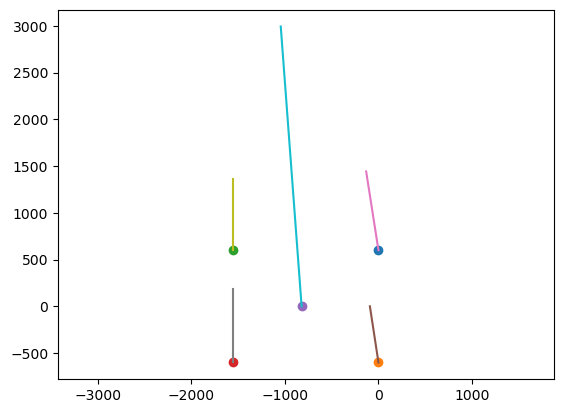

[2293.6856808483685, 1503.5477126860922, 2536.1944609730435, 1435.4583747876459]


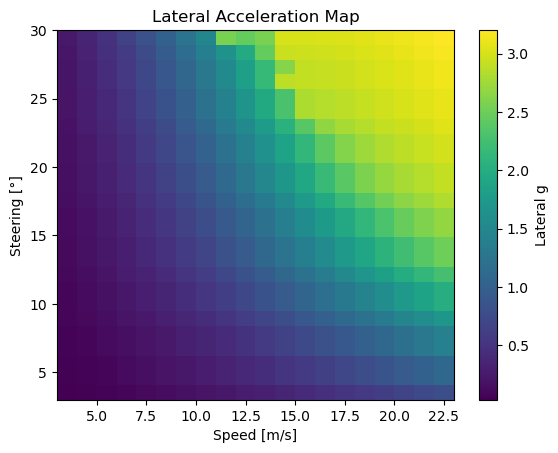

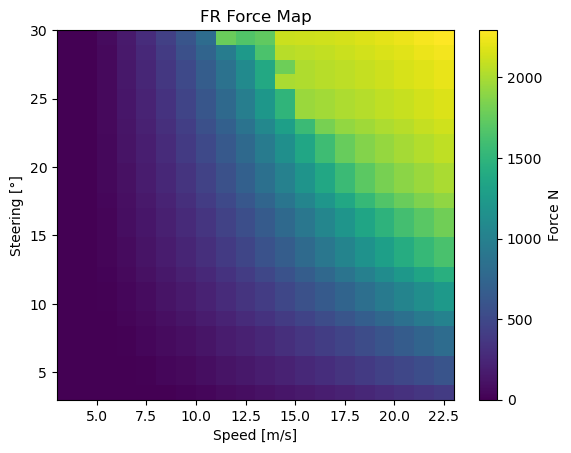

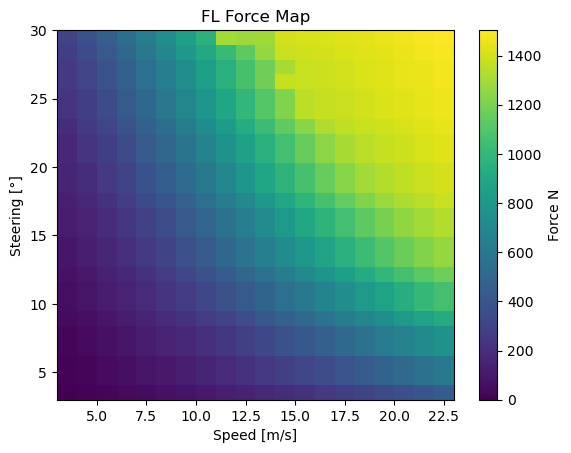

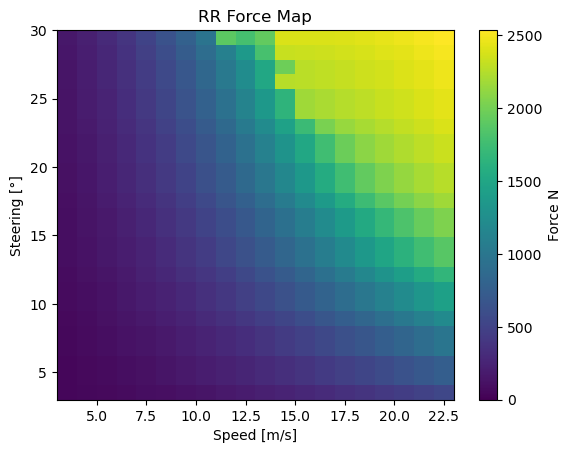

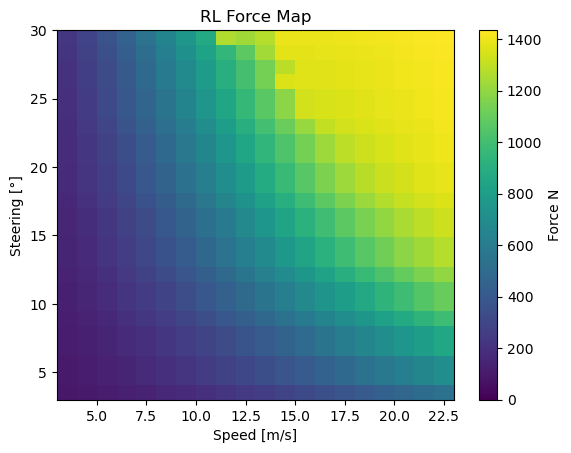

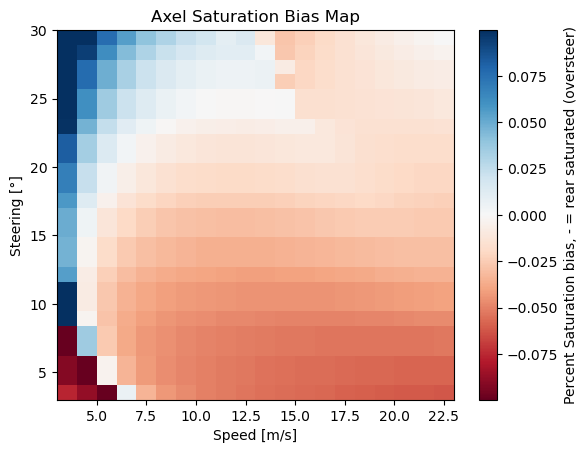

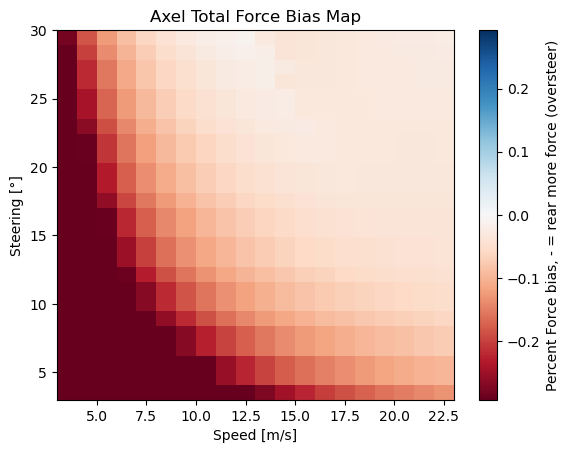

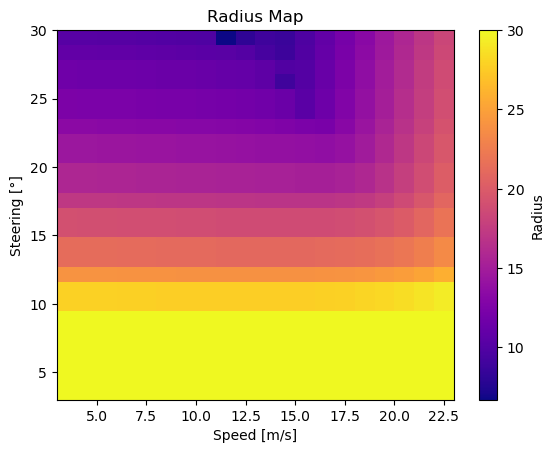

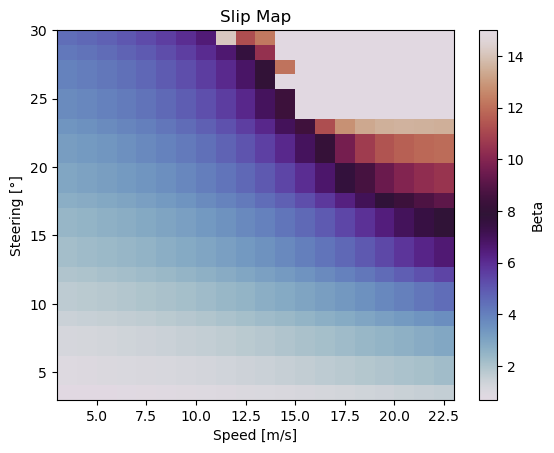

In [104]:



n_steer, n_speed = 25, 20
Fyyy = np.full((n_steer, n_speed), np.nan)
FFRyyy = np.full((n_steer, n_speed), np.nan)
FFLyyy = np.full((n_steer, n_speed), np.nan)
FRRyyy = np.full((n_steer, n_speed), np.nan)
FRLyyy = np.full((n_steer, n_speed), np.nan)
OUS = np.full((n_steer, n_speed), np.nan)
OUS2 = np.full((n_steer, n_speed), np.nan)

Ryyy = np.full((n_steer, n_speed), np.nan)
Byyy = np.full((n_steer, n_speed), np.nan)
FMAX= [0,0,0,0]

#'''
for i in range(n_steer):

    stepPer=(i+5)/100
    steerstep= int(np.round(stepPer * steps))

    steer= 15 /180*np.pi #radians
    steerr=ang[1,steerstep]# 15 /180*np.pi #radians #negative bc when calculatin steering the outside wheel was negative
    steerl=ang[0,steerstep]# 15 /180*np.pi #radians
    steer=( -steerr+steerl )/2#radians
    
    Fyy= []
    FFRyy= []
    FFLyy= []
    FRRyy= []
    FRLyy= []

    Ryy= []
    Byy= []
    for j in range(n_speed):
        beta0= (i/6 +j**2/2000)/180*np.pi #radians (offset from steering)
        U=j+5
        #print(U)
        solution, info, ier, msg = fsolve(
            steady_state, [beta0, 1/R0, phi0], xtol=1e-6, maxfev=20000, full_output=True
        )
        if ier != 1:
            # retry with a guess
            #print("fsolve did not converge:", msg)
            guess = [solution[0]*.99, .99*solution[1],.99*solution[2]]
            solution, info, ier, msg = fsolve(
                steady_state, guess, xtol=1e-4, maxfev=20000, full_output=True
            )
        try:
            # solve ...
            Fyyy[i,j] = round(Fy1/mg,4)
            FFRyyy[i,j] = round(Fw1[0],6)
            if Fw1[0]> FMAX[0]: FMAX[0]=Fw1[0]
            FFLyyy[i,j] = round(Fw1[1],6)
            if Fw1[1]> FMAX[1]: FMAX[1]=Fw1[1]
            FRRyyy[i,j] = round(Fw1[2],6)
            if Fw1[2]> FMAX[2]: FMAX[2]=Fw1[2]
            FRLyyy[i,j] = round(Fw1[3],6)
            if Fw1[3]> FMAX[3]: FMAX[3]=Fw1[3]
            

            Ryyy[i,j] = round(1/solution[1],4)
            Byyy[i,j] = round(solution[0]*180/np.pi,4)
        except Exception:
            # leave NaN
            pass

#'''
        #print(U)
MaxPerc=0
MaxPerc2=0
for i in range(n_steer):
    for j in range(n_speed):
        OUS[i,j] = \
        ((FFRyyy[i,j]**2/FMAX[0] +FFLyyy[i,j]**2/FMAX[1])/(FFRyyy[i,j]+FFLyyy[i,j]) \
         - (FRRyyy[i,j]**2/FMAX[2] +FRLyyy[i,j]**2/FMAX[3])/(FRRyyy[i,j]+FRLyyy[i,j]))\
        #+.5*((FFRyyy[i,j]-FFLyyy[i,j])/FFRyyy[i,j]) - .5*((FRRyyy[i,j]-FRLyyy[i,j])/FRRyyy[i,j])
        if abs(OUS[i,j])>MaxPerc and abs(OUS[i,j])<.1: 
            MaxPerc= abs(OUS[i,j])
            
        OUS2[i,j] = \
        ((FFRyyy[i,j] +FFLyyy[i,j])- (FRRyyy[i,j]+FRLyyy[i,j]))\
        /(FFRyyy[i,j] +FFLyyy[i,j] +FRRyyy[i,j]+FRLyyy[i,j])
        if abs(OUS2[i,j])>MaxPerc2 and abs(OUS2[i,j])<.3:
            MaxPerc2= abs(OUS2[i,j])
        
        
U= 11
stepPer=.3
steerstep= int(np.round(stepPer * steps))
steer= 15 /180*np.pi #radians
steerr=ang[1,steerstep]# 15 /180*np.pi #radians #negative bc when calculatin steering the outside wheel was negative
steerl=ang[0,steerstep]# 15 /180*np.pi #radians
steer=( -steerr+steerl )/2#radians
print(steer*180/np.pi)
solution, info, ier, msg = fsolve(
    steady_state, [beta0, 1/R0,phi0], xtol=1e-8, maxfev=20000, full_output=True
)
if ier != 1:
    # retry with a guess
    #print("fsolve did not converge:", msg)
    guess = [solution[0]*.99, .99*solution[1],.99*solution[2]]
    solution, info, ier, msg = fsolve(
        steady_state, guess, xtol=1e-6, maxfev=20000, full_output=True
    )
Fyy.append(round(Fy1/mg,4))
Ryy.append(round(1/solution[1],4))
#'''






prev_solution = solution
beta_sol, R_sol, phi_sol = solution
R_sol= 1/abs(R_sol)
beta_sol*=180/np.pi
#print("final ite")
#print(steady_state(solution))
print("\nsolution:", "\nbeta:",beta_sol, "R:", R_sol, "phi:", phi_sol*180/np.pi)
print("slip angles", alphalist)
print("x (scrub):",Fx2, np.sum(Fx2[:]), "g:",np.sum(Fx2[:])/(mg))
print("y (lateral force):",Fy2, np.sum(Fy2[:]), "g:",np.sum(Fy2[:])/(mg))
print("slip forces:",Fw1, np.sum(Fw1[:]), "g:",np.sum(Fw1[:])/(mg))
print("mu:", mu)
print("w", W)
print("cp magnitude:", cpmag)
print("total g:", Fy3, Fy3/mg, Fy3/(mg + cpmag))


CG= [-1*wheelbase*CGx,0]
plt.plot(0,track/2,"o")
plt.plot(0,-track/2,"o")
#plt.plot(0,0,"o")
plt.plot(-wheelbase,track/2,"o")
plt.plot(-wheelbase,-track/2,"o")
#plt.plot(-wheelbase,0,"o")
plt.plot(CG[0],CG[1], "o")


plt.plot([0,Fx2[0]],[-track/2,-track/2+Fy2[0]],"-")
plt.plot([0,Fx2[1]],[track/2,track/2+Fy2[1]],"-")
plt.plot([-wheelbase,-wheelbase+Fx2[2]],[-track/2,-track/2+Fy2[2]],"-")
plt.plot([-wheelbase,-wheelbase+Fx2[3]],[track/2,track/2+Fy2[3]],"-")
plt.plot([CG[0],CG[0]+np.sum(Fx2[:])],[CG[1],CG[1]+np.sum(Fy2[:])],"-")

plt.axis('equal')


F= mass * U**2 / (R_sol) *1000

Fy= Fyf+Fyr
#print(Fy, Fy/mg)
plt.show()
#print(af,ar)
#print(Ryyy)
#print(Fyyy)


#'''
import matplotlib.pyplot as plt
Fyyy = np.clip(Fyyy, 0, 4)  # Replace negatives with 0
R0yyy = np.clip(Ryyy, 0, 30)
print(FMAX)

MAX=2000 #N
"""FFRyyy = np.clip(FFRyyy, 0, MAX)
FFLyyy = np.clip(FFLyyy, 0, MAX)
FRRyyy = np.clip(FRRyyy, 0, MAX)
FRLyyy = np.clip(FRLyyy, 0, MAX)"""
Byyy = np.clip(Byyy, 0, 15)


plt.imshow(Fyyy, extent=[3,23,3,30], origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label='Lateral g')
plt.ylabel('Steering [°]')
plt.xlabel('Speed [m/s]')
plt.title('Lateral Acceleration Map')
plt.show()

#each wheel
plt.imshow(FFRyyy, extent=[3,23,3,30], origin='lower', cmap='viridis', aspect='auto', vmin=0)#, vmax=MAX)
plt.colorbar(label='Force N')
plt.ylabel('Steering [°]')
plt.xlabel('Speed [m/s]')
plt.title('FR Force Map')
plt.show()
plt.imshow(FFLyyy, extent=[3,23,3,30], origin='lower', cmap='viridis', aspect='auto', vmin=0)#, vmax=MAX)
plt.colorbar(label='Force N')
plt.ylabel('Steering [°]')
plt.xlabel('Speed [m/s]')
plt.title('FL Force Map')
plt.show()
plt.imshow(FRRyyy, extent=[3,23,3,30], origin='lower', cmap='viridis', aspect='auto', vmin=0)#, vmax=MAX)
plt.colorbar(label='Force N')
plt.ylabel('Steering [°]')
plt.xlabel('Speed [m/s]')
plt.title('RR Force Map')
plt.show()
plt.imshow(FRLyyy, extent=[3,23,3,30], origin='lower', cmap='viridis', aspect='auto', vmin=0)#, vmax=MAX)
plt.colorbar(label='Force N')
plt.ylabel('Steering [°]')
plt.xlabel('Speed [m/s]')
plt.title('RL Force Map')
plt.show()

plt.imshow(OUS, extent=[3,23,3,30], origin='lower', cmap='RdBu', aspect='auto', vmin=-MaxPerc, vmax=MaxPerc)#, vmax=MAX)
plt.colorbar(label='Percent Saturation bias, - = rear saturated (oversteer)')
plt.ylabel('Steering [°]')
plt.xlabel('Speed [m/s]')
plt.title('Axel Saturation Bias Map')
plt.show()
plt.imshow(OUS2, extent=[3,23,3,30], origin='lower', cmap='RdBu', aspect='auto', vmin=-MaxPerc2, vmax=MaxPerc2)#, vmax=MAX)
plt.colorbar(label='Percent Force bias, - = rear more force (oversteer)')
plt.ylabel('Steering [°]')
plt.xlabel('Speed [m/s]')
plt.title('Axel Total Force Bias Map')
plt.show()

plt.imshow(R0yyy, extent=[3,23,3,30], origin='lower', cmap='plasma', aspect='auto')
plt.colorbar(label='Radius')
plt.ylabel('Steering [°]')
plt.xlabel('Speed [m/s]')
plt.title('Radius Map')
plt.show()

plt.imshow(Byyy, extent=[3,23,3,30], origin='lower', cmap='twilight', aspect='auto')
plt.colorbar(label='Beta')
plt.ylabel('Steering [°]')
plt.xlabel('Speed [m/s]')
plt.title('Slip Map')
plt.show()
#'''

In [105]:
################transient